# EDA — [Spotify Tracks Dataset]

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv("../data/processed/clean_tracks.csv")
df.describe()
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217


### Question 1 : How is popularity distributed?

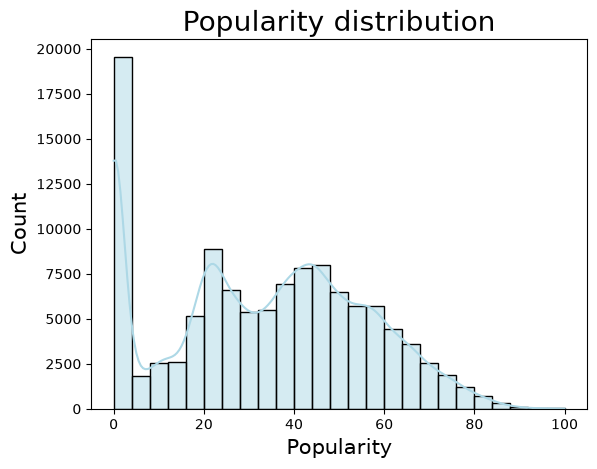

In [21]:
sns.histplot(df["popularity"], bins= 25, kde=True, color= "lightblue")
plt.title("Popularity distribution", fontsize = 20)
plt.xlabel("Popularity" , fontsize= 15)
plt.ylabel("Count" , fontsize= 15)
plt.savefig("../visuals/popularity_dist.png", dpi=300)

 # Insights >
 - most of the  tracks cluster around popularity  0 - 60few hits above 80 
 - the curve is non symetric ...

### Question 2 : How is tempo is  distributed? 
-  here tempo is Speed of the song in beats per minute (BPM) 
- E.X Slow = 70 BPM, Dance = 120–140 BPM.

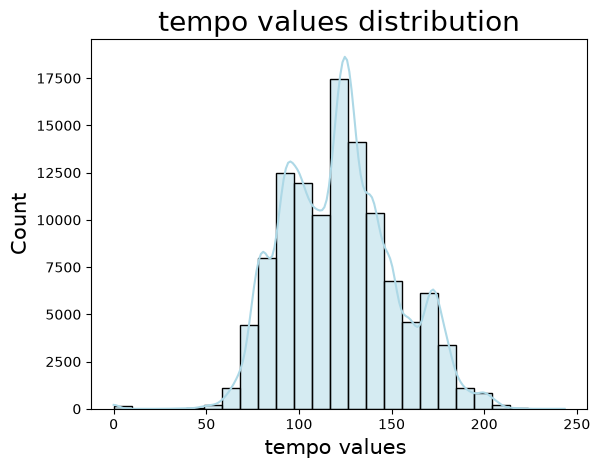

In [22]:
sns.histplot(df["tempo"], bins= 25, kde=True, color= "lightblue")
plt.title("tempo values distribution", fontsize = 20)
plt.xlabel("tempo values " , fontsize= 15)
plt.ylabel("Count" , fontsize= 15)
plt.savefig("../visuals/tempo_dist.png", dpi=300)

 # Insights >
 - Tempo peaks around 120–130 BPM, consistent with dance-genre tracks dominating the dataset
 - There is a potential outlier near 0 BPM, which may represent missing or erroneous data 

### Question 3:  How are explicit and non-explicit songs distributed in the dataset?
- here [(Explicit content) refers to songs containing strong language ]

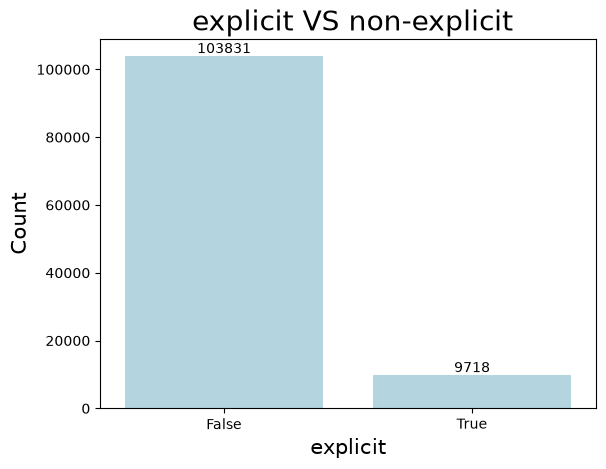

In [36]:
expl_count = df["explicit"].value_counts()
ax= sns.barplot(expl_count , color= "lightblue")
ax.bar_label(ax.containers[0])
plt.title(" explicit VS non-explicit", fontsize = 20)
plt.xlabel("explicit" , fontsize= 15)
plt.ylabel("Count" , fontsize= 15)
plt.savefig("../visuals/explicity.png", dpi=300)

 # Insights >
 - The dataset is heavily dominated by non-explicit songs
 - Approximately 91% of the songs are non-explicit, while only about 9% are explicit


### Question 4:  How are songs distributed between major and minor musical keys?
- here >
- A song in a major key can sound emotional or melancholic.
- A song in a minor key can sound energetic or uplifting

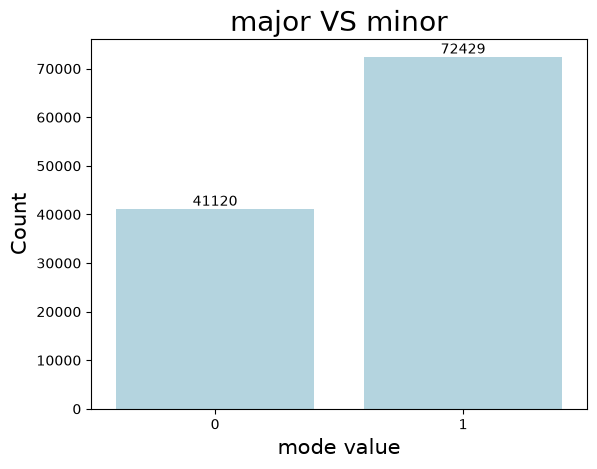

In [128]:
mode_count = df["mode"].value_counts()
ax= sns.barplot(mode_count , color= "lightblue")
ax.bar_label(ax.containers[0])
plt.title(" major VS minor ", fontsize = 20)
plt.xlabel("mode value" , fontsize= 15)
plt.ylabel("Count" , fontsize= 15)
plt.savefig("../visuals/Mode.png", dpi=300)


# Insights >
- The dataset contains more songs in the major key than in the minor key
- Major-key[1] songs account for approximately 64% of the dataset, while minor-key[0] songs make up about 36%

### Question 5 : Which time signature is the most common among the tracks? ?
- here [time_signature] Number of beats per measure

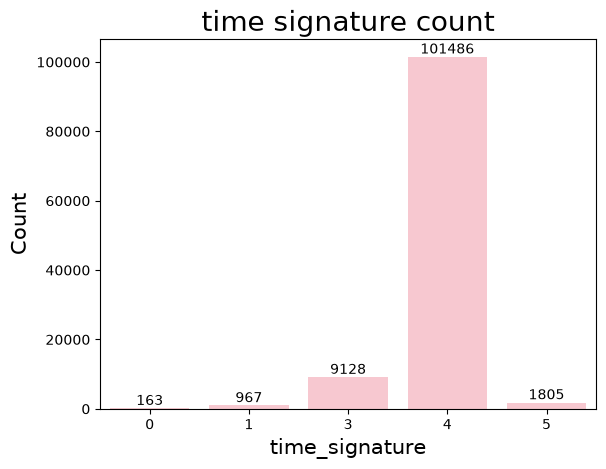

In [79]:
time_sig_count = df["time_signature"].value_counts()
tim_sig_perc= (df["time_signature"].value_counts(normalize=True) * 100).round(2)
ax = sns.barplot(time_sig_count , color= "pink" )
ax.bar_label(ax.containers[0])
plt.title("time signature count" , fontsize= 20)
plt.xlabel("time_signature" , fontsize= 15)
plt.ylabel("Count", fontsize = 15)
plt.savefig("../visuals/time_signature.png" , dpi= 300)


# Insights >
- most of the music 89.38% use  a 4/4  time signature 
- Time signatures such as 3/4 (8.04)% and 5/4 (1.59)% are much less common
- A very small number (0.85 ~ 0.14)% of tracks have time signatures of 0 or 1, which may represent missing, unknown

###  Question 6: Which artists have the most tracks in the dataset?

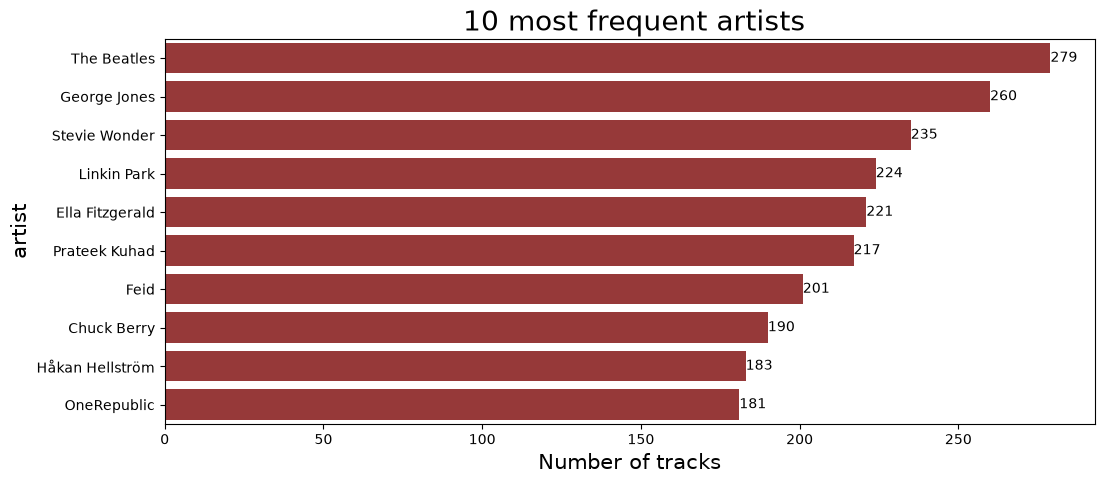

In [129]:
top_artists = df["artists"].value_counts().head(10)
plt.figure(figsize= (12 ,5))
ax= sns.barplot(x= top_artists, y = top_artists.index , color= "brown")
ax.bar_label(ax.containers[0])
plt.title(" 10 most frequent artists" , fontsize= 20)
plt.xlabel("Number of tracks" , fontsize= 15)
plt.ylabel("artist", fontsize = 15)
plt.savefig("../visuals/to 10 artists.png" , dpi= 300)


# Insights >
- The dataset is dominated by a small number of artists, with the top 10 artists contributing the largest number of tracks.
- The mvp  of this data set is artist "the beatles" with highest  279 no. of tracks 
- the 2nd mvp of this set is artis "George jones" with 260 no. of tracks 
-  and linkin park is my fav :)

### Question 7: Which albums contain the most tracks in the dataset?

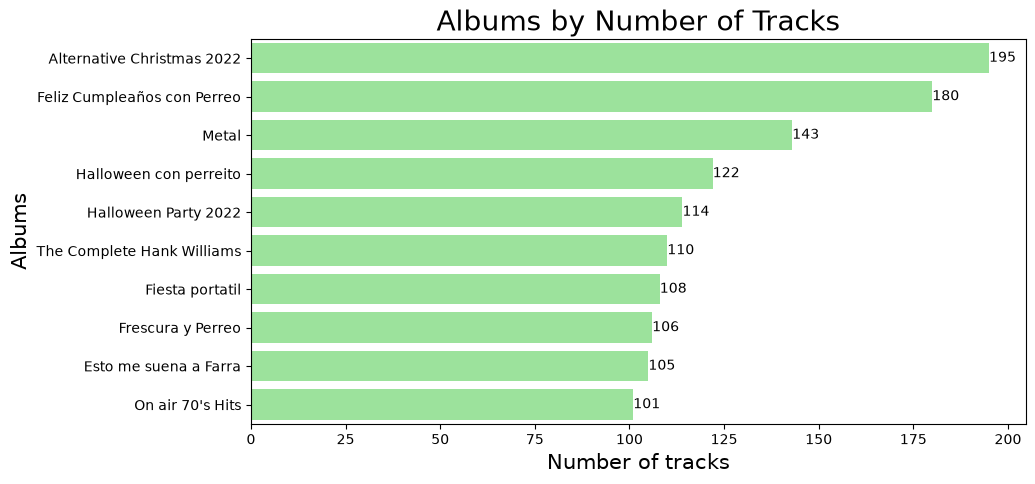

In [127]:
top_albums = df["album_name"].value_counts().head(10)
plt.figure(figsize=(10 , 5))
ax= sns.barplot(x= top_albums , y = top_albums.index , color="lightgreen" )
ax.bar_label(ax.containers[0])
plt.title("Albums by Number of Tracks", fontsize= 20)
plt.xlabel("Number of tracks" , fontsize= 15)
plt.ylabel("Albums", fontsize = 15)
plt.savefig("../visuals/top albums.png" , dpi= 300)


# Insights>
- "Alternative Christmas 2022" contains the highest number of tracks (195) in the dataset
- the top 10 albums each contain more than 100 tracks, indicating that these albums are well represented in the dataset
- the difference in track counts between the top-ranked albums is relatively small means fairly balanced distribution